<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK11_%ED%95%84%EC%82%AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8.3 하이퍼파라미터를 이용한 성능 최적화

배치 정규화, 드롭아웃, 조기 종료

## 8.3.1 배치 정규화를 이용한 성능 최적화

**정규화**: 데이터 범위를 사용자가 원하는 범위로 제한하는 것. 각 특성 범위를 조정한다는 의미로 특성 스케일링이라고도 하며, MinMaxScaler 기법을 이용.

**규제화**: 모델의 복잡도를 줄이기 위해 제약을 두는 방법. (드롭아웃, 조기 종료)

**표준화**: 기존 데이터를 평균 0, 표준편차 1인 형태의 데이터로 만드는 방법.데이터 분포가 가우시안 분포를 따를 때 유용한 방법.

**배치 정규화**: 기울기 소멸, 기울기 폭발 같은 문제를 해결하기 위한 방법. 손실 함수로 렐루를 사용하거나 초깃값 튜닝, 학습률 등을 조정. 내부 공변량 변화(네트워크의 각 층마다 활성화 함수가 적용되면서 입력값들의 분포가 계속 바뀌는 현상)으로 인한 문제를 해결함.
- 기울기 소멸: 오차 정보를 역전파시키는 과정에서 기울기가 급격히 0에 가까워져 학습이 되지 않는 현상
- 기울기 폭발: 학습 과정에서 기울기가 급격히 커지는 현상
- 단점: 1. 배치 크기가 작을 때 정규화 값이 기존 값과 다른 방향으로 훈련될 수 있음. 2. RNN은 네트워크 계층별로 미니 정규화를 적용해야 하기 때문에 모델이 더 복잡해지면서 비효율적일 수 있음.

## 8.3.2 드롭아웃을 이용한 성능 최적화

드롭아웃: 훈련할 때 일정 비율의 뉴런만 사용하고, 나머지 뉴런에 해당하는 가중치는 업데이트하지 않는 방법. 노드를 임의로 끄면서 학습하는 방법으로, 은닉층에 배치된 노드 중 일부를 임의로 끄면서 학습. 꺼진 노드는 신호를 전달하지 않으므로 지나친 학습을 방지하는 효과가 생김. 훈련 시간이 길어지나, 모델 성능을 향상시킬 수 있음.

In [1]:
# 코드 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [2]:
# 코드 8-2 데이터셋 내려받기
trainset=torchvision.datasets.FashionMNIST(
    root='../chap08/data/',train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.3MB/s]


In [3]:
# 코드 8-3 데이터셋을 메모리로 가져오기
batch_size=4
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)

In [5]:
dataiter=iter(trainloader)
images,labels=next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
7


In [6]:
# 코드 8-5 이미지 데이터를 출력하기 위한 전처리
def imshow(img,title):
  plt.figure(figsize=(batch_size*4,4))
  plt.axis('off')
  plt.imshow(np.transpose(img,(1,2,0)))
  plt.title(title)
  plt.show()

In [9]:
# 코드 8-6 이미지 데이터 출력 함수
def show_batch_images(dataloader):
  images,labels=next(iter(dataloader))

  img=torchvision.utils.make_grid(images)
  imshow(img,title=[str(x.item()) for x in labels])

  return images,labels

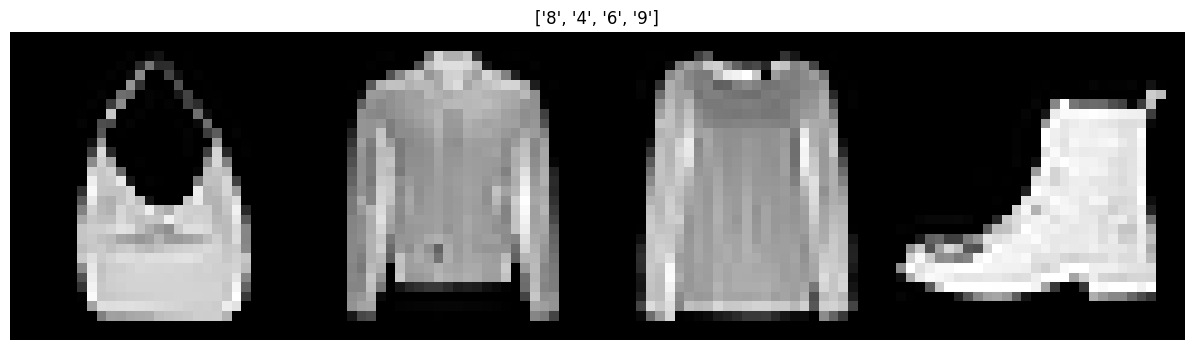

In [10]:
# 코드 8-7 이미지 출력
images,labels=show_batch_images(trainloader)

In [11]:
# 코드 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet,self).__init__()
    self.classifier=nn.Sequential(
        nn.Linear(784,48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.ReLU(),
        nn.Linear(24,10)
    )

  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.classifier(x)
    return x

In [12]:
# 코드 8-9 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet,self).__init__()
    self.classifier=nn.Sequential(
        nn.Linear(784,48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48,24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24,10)
    )

  def forward(self,x):
    x=x.view(x.size(0),-1)
    x=self.classifier(x)
    return x

은닉층에서 학습이 진행될 때마다 입력 분포가 변하면서 가중치가 엉뚱한 방향으로 갱신되는 문제가 있어 배치 정규화를 적용해 입력 분포를 고르게 맞춤.

배치 정규화 위치: FC > **BN** > tanh > FC > **BN** > tanh ... (완전연결층과 합성곱층 뒤, 활성화함수 앞에 위치)

In [13]:
# 코드 8-10 배치 정규화가 적용되지 않은 모델 선언
model=NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [14]:
# 코드 8-11 배치 정규화가 적용된 모델 선언
model_bn=BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [15]:
# 코드 8-12 데이터셋 메모리로 불러오기
batch_size=512
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)

In [16]:
# 코드 8-13 옵티마이저, 손실 함수 지정
loss_fn=nn.CrossEntropyLoss()
opt=optim.SGD(model.parameters(),lr=0.01)
opt_bn=optim.SGD(model_bn.parameters(),lr=0.01)

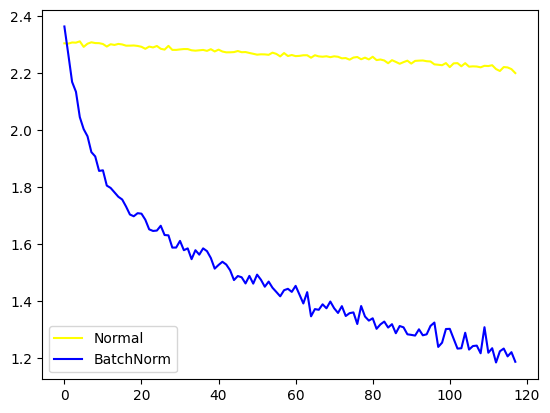

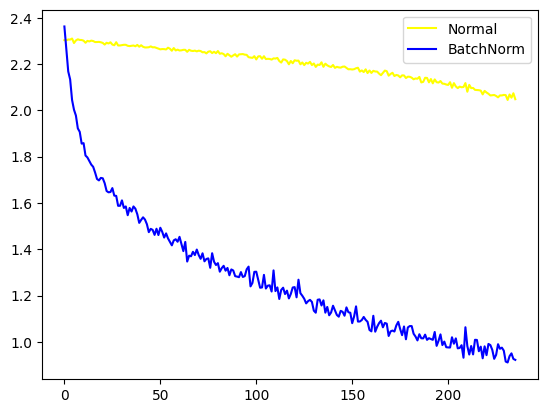

In [18]:
# 코드 8-14 모델 학습
loss_arr=[]
loss_bn_arr=[]
max_epochs=2

for epoch in range(max_epochs):
  for i,data in enumerate(trainloader,0):
    inputs,labels=data
    opt.zero_grad()
    outputs=model(inputs)
    loss=loss_fn(outputs,labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad()
    outputs_bn=model_bn(inputs)
    loss_bn=loss_fn(outputs_bn,labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr,'yellow',label='Normal')
  plt.plot(loss_bn_arr,'blue',label='BatchNorm')
  plt.legend()
  plt.show()

In [19]:
# 코드 8-15 데이터셋의 분포를 출력하기 위한 전처리
N=50
noise=0.3

x_train=torch.unsqueeze(torch.linspace(-1,1,N),1)
y_train=x_train+noise*torch.normal(torch.zeros(N,1),torch.ones(N,1))

x_test=torch.unsqueeze(torch.linspace(-1,1,N),1)
y_test=x_test+noise*torch.normal(torch.zeros(N,1),torch.ones(N,1))

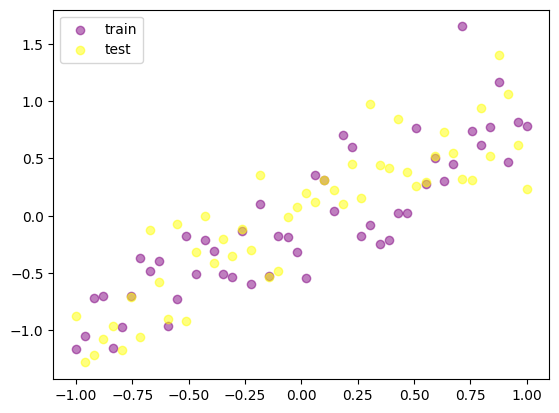

In [20]:
# 코드 8-16 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(),y_train.data.numpy(),c='purple',alpha=0.5,label='train')
plt.scatter(x_test.data.numpy(),y_test.data.numpy(),c='yellow',alpha=0.5,label='test')
plt.legend()
plt.show()

In [21]:
# 코드 8-17 드롭아웃을 위한 모델 생성
N_h=100
model=torch.nn.Sequential(
    torch.nn.Linear(1,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1),
)

model_dropout=torch.nn.Sequential(
    torch.nn.Linear(1,N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h,1),
)

In [22]:
# 코드 8-18 옵티마이저와 손실 함수 지정
opt=torch.optim.Adam(model.parameters(),lr=0.01)
opt_dropout=torch.optim.Adam(model_dropout.parameters(),lr=0.01)
loss_fn=torch.nn.MSELoss()

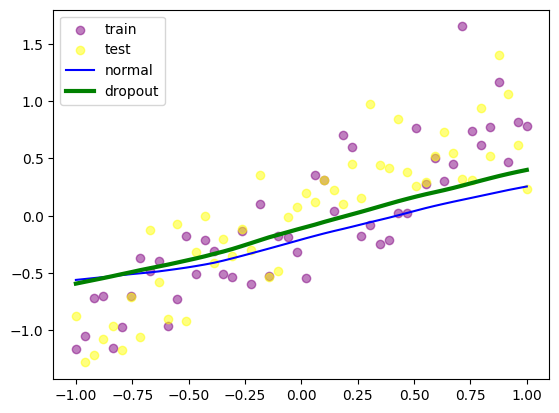

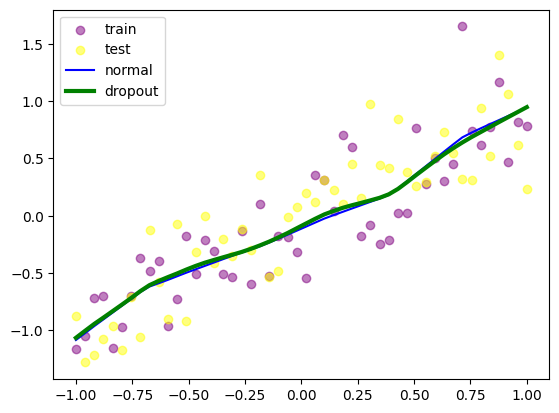

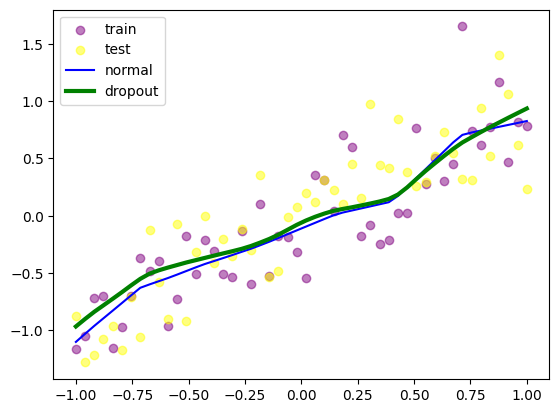

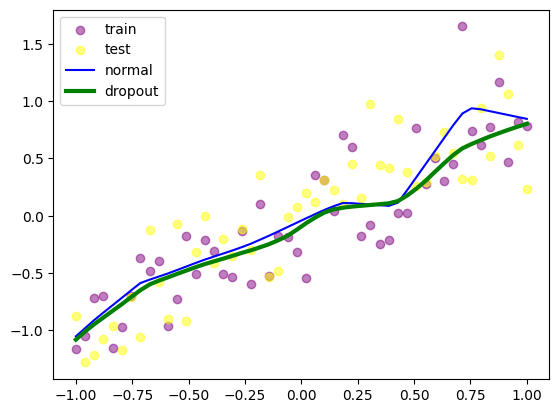

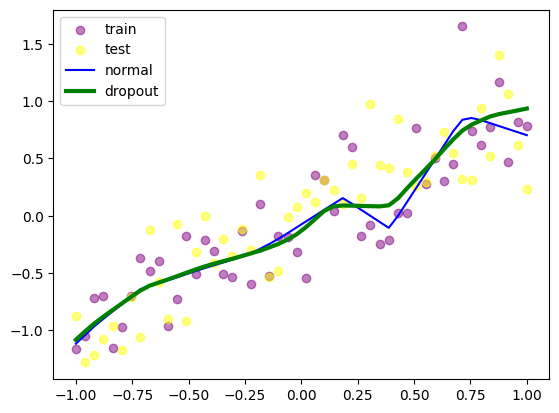

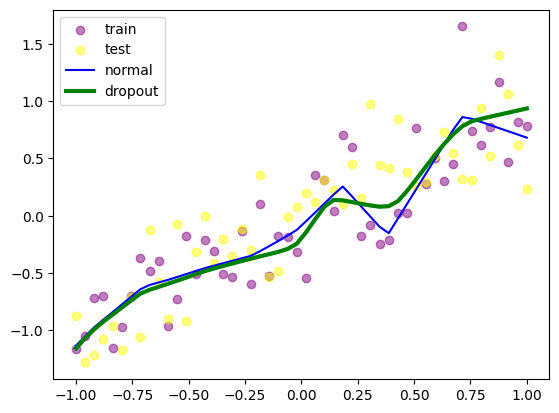

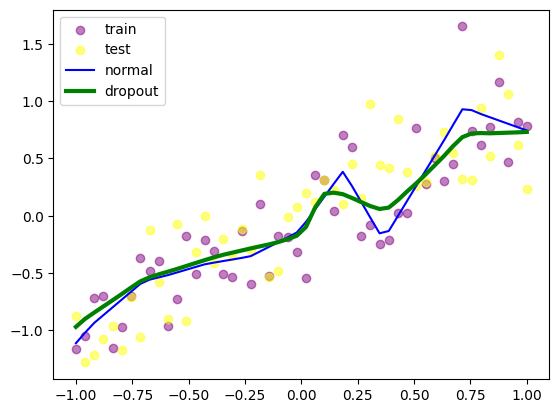

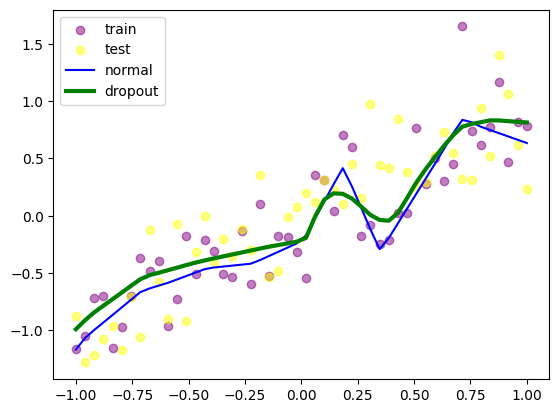

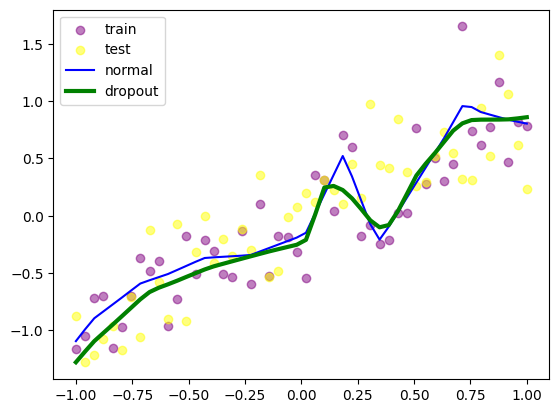

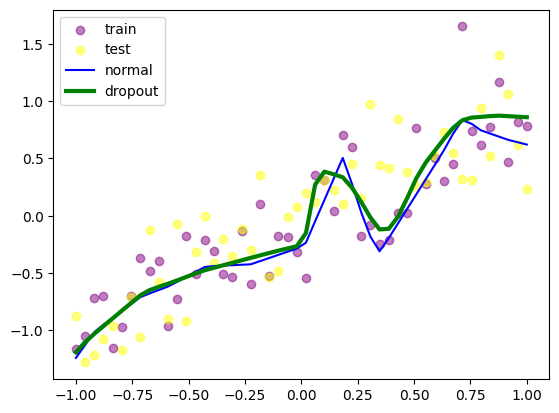

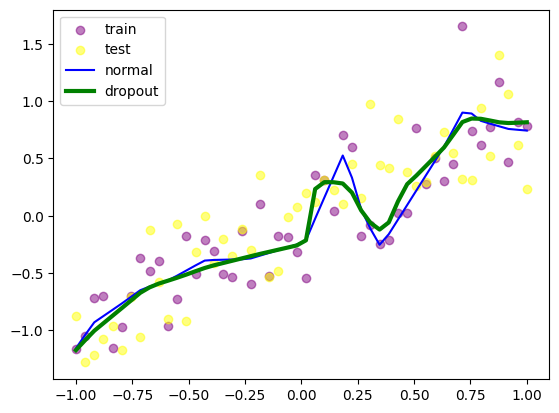

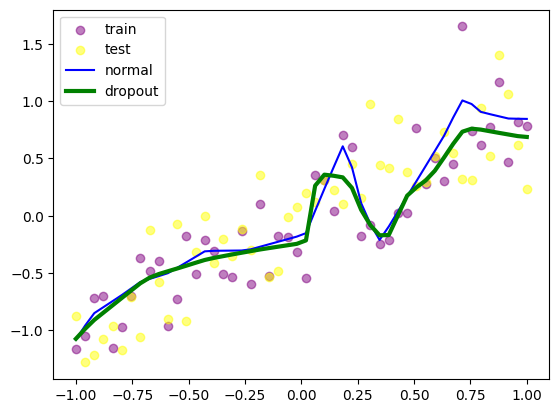

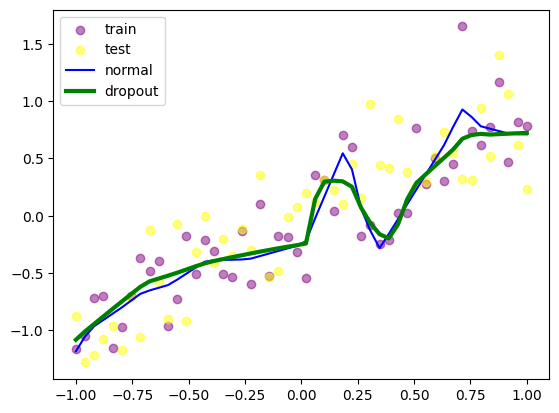

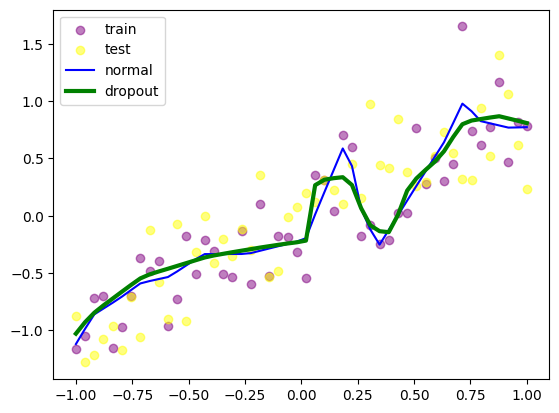

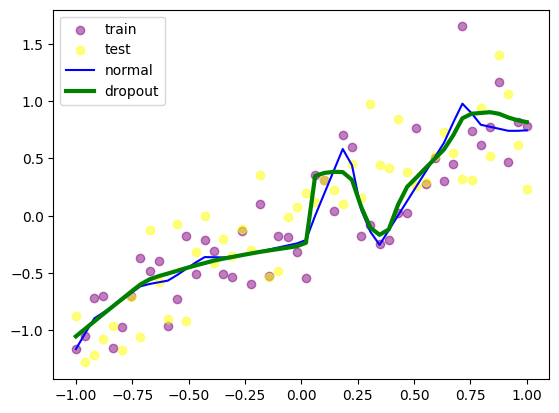

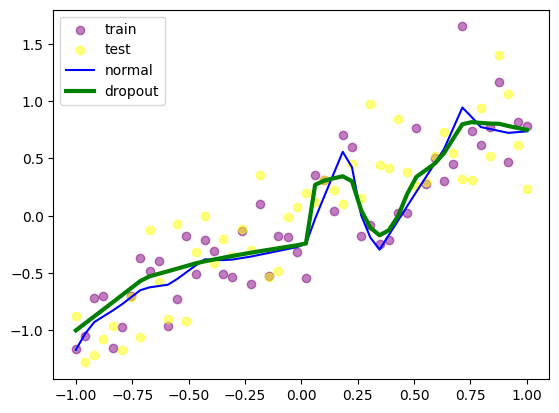

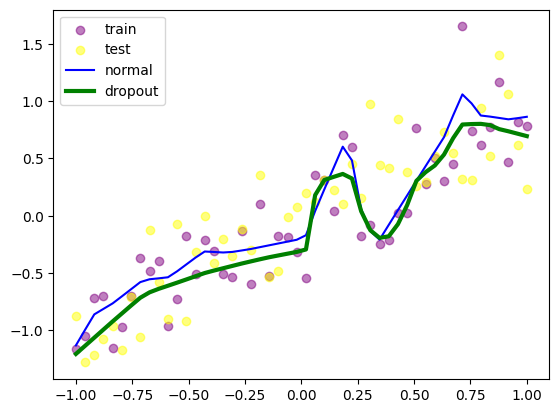

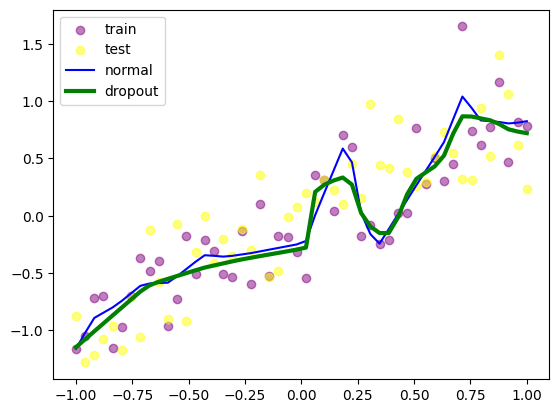

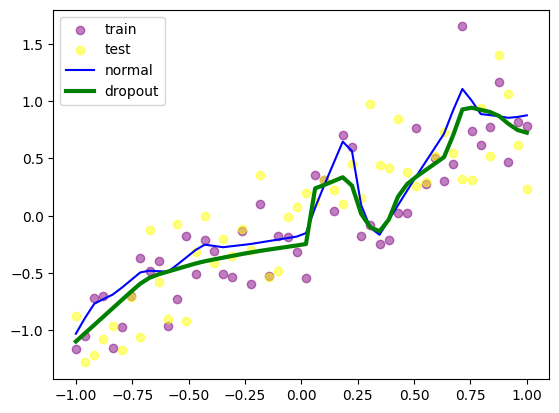

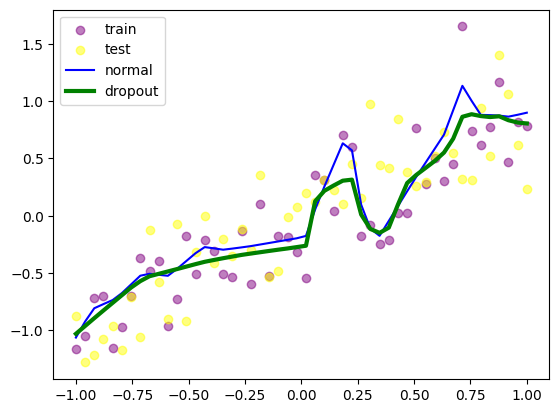

In [26]:
# 코드 8-19 모델 학습
max_epochs=1000
for epoch in range(max_epochs):
  pred=model(x_train)
  loss=loss_fn(pred,y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout=model_dropout(x_train)
  loss_dropout=loss_fn(pred_dropout,y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch%50==0:
    model.eval()
    model_dropout.eval()

    test_pred=model(x_test)
    test_loss=loss_fn(test_pred,y_test)

    test_pred_dropout=model_dropout(x_test)
    test_loss_dropout=loss_fn(test_pred_dropout,y_test)

    plt.scatter(x_train.data.numpy(),y_train.data.numpy(),c='purple',alpha=0.5,label='train')
    plt.scatter(x_test.data.numpy(),y_test.data.numpy(),c='yellow',alpha=0.5,label='test')
    plt.plot(x_test.data.numpy(),test_pred.data.numpy(),'b-',label='normal')
    plt.plot(x_test.data.numpy(),test_pred_dropout.data.numpy(),'g-',lw=3,label='dropout')
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

## 8.3.3 조기 종료를 이용한 성능 최적화

조기 종료: 뉴럴 네트워크가 과적합을 회피하는 규제 기법. 훈련 데이터와 별도로 검증 데이터를 준비하고, 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델의 종료 시점을 제어. 검증 데이터셋에 대한 오차가 증가하는 시점에서 학습을 멈추도록 조정.
- 학습률 감소: 학습이 진행되는 과정에서 학습률을 조금씩 낮추어 주는 성능 튜닝 기법. 학습률 스케줄러를 이용하며, 주어진 patience 횟수만큼 검증 데이터셋에 대한 오차 감소가 없으면 주어진 factor만큼 학습률을 감소시켜 모델 학습을 최적화.
- call back 함수: 특정 이벤트 발생에 의해 함수를 호출하고 처리하도록 하는 것. 동기적 함수(위에서 아래로, 왼쪽에서 오른쪽으로 순차 진행)/비동기적 함수(병렬 처리)가 있음.

In [27]:
# 코드 8-20 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms,datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [29]:
# 코드 8-21 데이터셋 전처리
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

In [31]:
# 코드 8-22 데이터셋 가져오기
!git clone https://github.com/gilbutITbook/080289.git
train_path = './080289/chap08/data/archive/train'
test_path = './080289/chap08/data/archive/test'

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_dataset = datasets.ImageFolder(
    root=test_path,
    transform=val_transform
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 41.98 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [32]:
# 코드 8-23 모델 생성
def resnet50(pretrained=True,requires_grad=False):
  model=models.resnet50(progress=True,pretrained=pretrained)
  if requires_grad==False:
    for param in model.parameters():
      param.requires_grad=False
  elif requires_grad==True:
    for param in model.parameters():
      param.requires_grad=True
  model.fc=nn.Linear(2048,2)
  return model

In [36]:
# 코드 8-24 학습률 감소
class LRScheduler():
  def __init__(
      self,optimizer,patience=5,min_lr=1e-6,factor=0.5
  ):
    self.optimizer=optimizer
    self.patience=patience
    self.min_lr=min_lr
    self.factor=factor
    self.lr_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=self.optimizer,
        mode='min',
        patience=self.patience,
        factor=self.factor,
        min_lr=self.min_lr,
        verbose=True
    )
  def __call__(self,val_loss):
    self.lr_scheduler.step(val_loss)

In [39]:
# 코드 8-25 조기 종료
class EarlyStopping():
  def __init__(self,patience=5,verbose=False,delta=0,
               path='../chap08/data/checkpoint.pt'):
    self.patience=patience
    self.verbose=verbose
    self.counter=0
    self.best_score=None
    self.early_stop=False
    self.val_loss_min=np.Inf
    self.delta=delta
    self.path=path

  def __call__(self,val_loss,model):
    score=-val_loss
    if self.best_score is None:
      self.best_score=score
      self.save_checkpoint(val_loss,model)
    elif score<self.best_score+self.delta:
      self.counter+=1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter>=self.patience:
        self.early_stop=True
    else:
      self.best_score=score
      self.save_checkpoint(val_loss,model)
      self.counter=0

  def save_checkpoint(self,val_loss,model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...')
    torch.save(model.state_dict(),self.path)
    self.val_loss_min=val_loss

In [41]:
# 코드 8-26 인수 값 지정
parser=argparse.ArgumentParser()
parser.add_argument('--lr-scheduler',dest='lr_scheduler',action='store_true')
parser.add_argument('--early-stopping',dest='early_stopping',action='store_true')
args, unknown = parser.parse_known_args()
args = vars(args)

In [42]:
# 코드 8-27 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n")
model=models.resnet50(pretrained=True).to(device)
total_params=sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters,")
total_trainable_params=sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


25,557,032 total parameters,
25,557,032 training parameters.


In [43]:
# 코드 8-28 옵티마이저와 손실 함수 지정
lr=0.001
epochs=100
optimizer=optim.Adam(model.parameters(),lr=lr)
criterion=nn.CrossEntropyLoss()

In [44]:
# 코드 8-29 오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name='loss'
acc_plot_name='accuracy'
model_name='model'

In [45]:
# 코드 8-30 오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler=LRScheduler(optimizer)
  loss_plot_name='lrs_loss'
  acc_plot_name='lrs_accuracy'
  model_name='lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping=EarlyStopping()
  loss_plot_name='es_loss'
  acc_plot_name='es_accuracy'
  model_name='es_model'

In [46]:
# 코드 8-31 모델 학습 함수
def training(model,train_dataloader,train_dataset,optimizer,criterion):
  print('Training')
  model.train()
  train_running_loss=0.0
  train_running_correct=0
  counter=0
  total=0
  prog_bar=tqdm(enumerate(train_dataloader),total=int(len(train_dataset)/train_dataloader.batch_size))
  for i,data in prog_bar:
    counter+=1
    data,target=data[0].to(device),data[1].to(device)
    total+=target .size(0)
    optimizer.zero_grad()
    outputs=model(data)
    loss=criterion(outputs,target)
    train_running_loss+=loss.item()
    _,preds=torch.max(outputs.data,1)
    train_running_correct+=(preds==target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss=train_running_loss/counter
  train_accuracy=100.*train_running_correct/total
  return train_loss,train_accuracy

In [47]:
# 코드 8-32 모델 검증 함수
def validate(model,test_dataloader,val_dataset,criterion):
  print('Validating')
  model.eval()
  val_running_loss=0.0
  val_running_correct=0
  counter=0
  total=0
  prog_bar=tqdm(enumerate(test_dataloader),total=int(len(val_dataset)/test_dataloader.batch_size))
  with torch.no_grad():
    for i,data in prog_bar:
      counter+=1
      data,target=data[0].to(device),data[1].to(device)
      total+=target.size(0)
      outputs=model(data)
      loss=criterion(outputs,target)

      val_running_loss+=loss.item()
      _,preds=torch.max(outputs.data,1)
      val_running_correct+=(preds==target).sum().item()

    val_loss=val_running_loss/counter
    val_accuracy=100.*val_running_correct/total
    return val_loss,val_accuracy

In [48]:
# 코드 8-33 모델 학습
train_loss,train_accuracy=[],[]

val_loss,val_accuracy=[],[]

start=time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss,train_epoch_accuracy=training(
      model,train_dataloader,train_dataset,optimizer,criterion
  )
  val_epoch_loss,val_epoch_accuracy=validate(
      model,val_dataloader,val_dataset,criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss,model)
    if early_stopping.early_stop:
      print("Early stopping")
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
end=time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:06,  2.64it/s]


Validating


16it [00:05,  3.07it/s]


Train Loss: 2.2096, Train Acc: 57.03
Val Loss: 6.0446, Val Acc: 58.20
Epoch 2 of 100
Training


...

Train Loss: 0.1202, Train Acc: 95.78
Val Loss: 1.3583, Val Acc: 75.60
Epoch 100 of 100
Training


16it [00:05,  3.07it/s]


Validating


16it [00:03,  4.57it/s]

Train Loss: 0.1824, Train Acc: 92.97
Val Loss: 2.4203, Val Acc: 66.80
Training time: 14.674 minutes


Saving loss and accuracy plots...


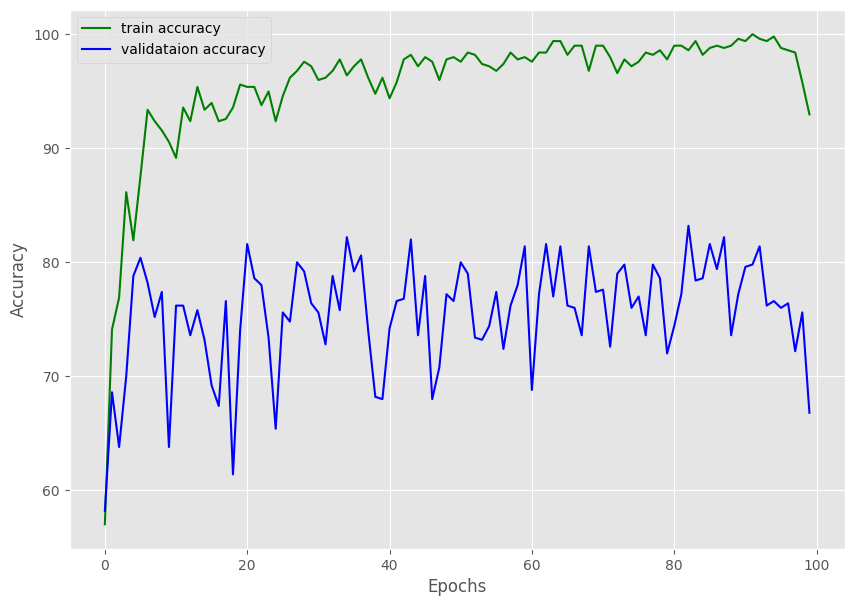

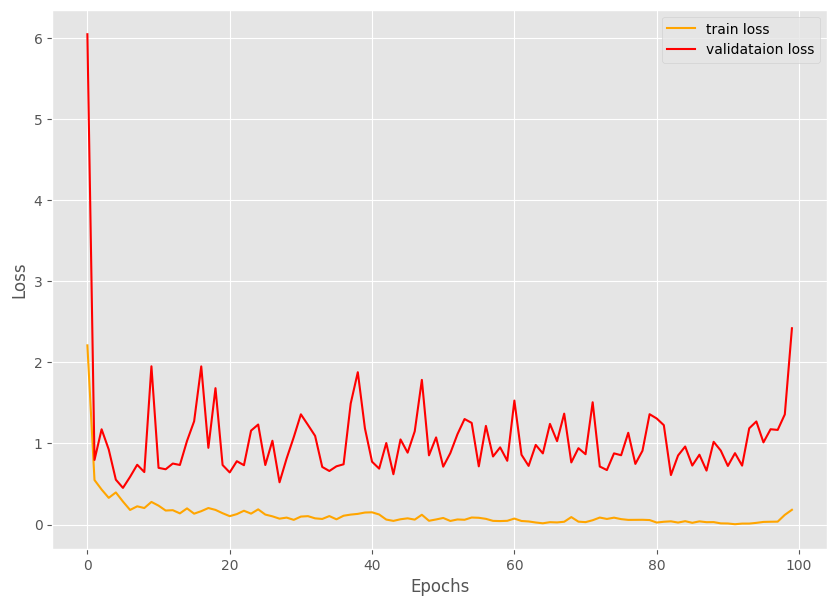

Saving model...
TRAINING COMPLETE


In [50]:
import os

# 코드 8-34 모델 학습 결과 출력
print('Saving loss and accuracy plots...')
plt.figure(figsize=(10,7))
plt.plot(train_accuracy,color='green',label='train accuracy')
plt.plot(val_accuracy,color='blue',label='validataion accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"{loss_plot_name}.png")
plt.show()
plt.figure(figsize=(10,7))
plt.plot(train_loss,color='orange',label='train loss')
plt.plot(val_loss,color='red',label='validataion loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Create the directory if it doesn't exist
os.makedirs('../chap08/img/', exist_ok=True)
plt.savefig(f"../chap08/img/{loss_plot_name}.png")
plt.show()

print('Saving model...')

# Create the directory for the model if it doesn't exist
os.makedirs('../chap08/data/', exist_ok=True)
torch.save(model.state_dict(),f"../chap08/data/{model_name}.pth")
print('TRAINING COMPLETE')